# 🧹 Tokenización y Preprocesamiento de Texto

## Limpieza y Preparación de Datos para NLP

En este notebook aprenderás cómo **preparar el texto** para que los modelos de Machine Learning lo puedan procesar correctamente.

### Objetivos del Notebook:
1. **Entender la tokenización** (dividir texto en palabras)
2. **Limpiar el texto** (remover HTML, URLs, puntuación)
3. **Remover stopwords** (palabras sin significado)
4. **Comparar Stemming vs Lemmatization**
5. **Crear un pipeline completo** de preprocesamiento
6. **Visualizar el impacto** de cada paso
7. **Evaluar la importancia** del preprocesamiento

### ¿Por qué Preprocesar Texto?

El texto raw (sin procesar) contiene mucho "ruido":
```
Review original:
"This movie is AMAZING!!! Check it out at www.imdb.com. 
It's the best <br> film I've ever seen... Don't miss it!!!!"

Después de preprocesar:
"movie amazing check film seen miss"
```

El texto limpio:
- ✅ Es más pequeño (menos memoria)
- ✅ Reduce ruido (mejora el modelo)
- ✅ Normaliza variaciones ("amazing", "AMAZING", "amazingly" → 1 concepto)
- ✅ Mejora la precisión del modelo

## Parte 1: Configuración Inicial

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tag import pos_tag

# Descargar recursos necesarios de NLTK
print("⏳ Descargando recursos de NLTK...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)  # Para versiones nuevas de NLTK
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('wordnet_ic', quiet=True)  # Adicional para lemmatization mejorado
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)  # Para mapeos de wordnet
print("✅ Recursos NLTK descargados")

# Configurar visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

print("✅ Librerías importadas correctamente")

⏳ Descargando recursos de NLTK...
✅ Recursos NLTK descargados
✅ Librerías importadas correctamente


In [2]:
# Configurar rutas del proyecto
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_RAW_DIR = PROJECT_DIR / 'data' / 'raw'
REPORTS_DIR = PROJECT_DIR / 'reports'

# Crear directorios si no existen
DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Rutas configuradas")
print(f"   - Proyecto: {PROJECT_DIR}")
print(f"   - Reportes: {REPORTS_DIR}")

📁 Rutas configuradas
   - Proyecto: d:\work\repos-deep-learning\sentiment-analysis
   - Reportes: d:\work\repos-deep-learning\sentiment-analysis\reports


## Parte 2: Tokenización

### ¿Qué es la Tokenización?

Es el proceso de dividir el texto en **unidades más pequeñas** (tokens), generalmente palabras o sentencias.

```
Texto original:  "This movie is great! I loved it."
Tokens:          ["This", "movie", "is", "great", "!", "I", "loved", "it", "."]
```

In [3]:
# CARGAR DATASET IMDB REAL
print("=" * 70)
print("📥 CARGANDO DATASET IMDB REAL")
print("=" * 70)

from tensorflow.keras.datasets import imdb

print("\n⏳ Descargando dataset...")
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Obtener diccionario de palabras
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

# Función para decodificar reviews
def decode_review(encoded_review, reverse_word_index):
    """Convierte review tokenizada (números) a texto."""
    decoded_text = ""
    for word_idx in encoded_review:
        if word_idx >= 3:
            decoded_text += " " + reverse_word_index.get(word_idx, "<unknown>")
    return decoded_text.strip()

print(f"✅ Dataset cargado: {len(X_train)} reviews de entrenamiento")

# Seleccionar 3 reviews reales para ejemplos (positivas y negativas)
positive_indices = [i for i, label in enumerate(y_train[:1000]) if label == 1][:1]
negative_indices = [i for i, label in enumerate(y_train[:1000]) if label == 0][:1]
mixed_indices = [i for i, label in enumerate(y_train[1000:1100]) if label == 1][:1]

example_reviews = [
    decode_review(X_train[positive_indices[0]], reverse_word_index),
    decode_review(X_train[negative_indices[0]], reverse_word_index),
    decode_review(X_train[mixed_indices[0]], reverse_word_index)
]

print("\n" + "=" * 70)
print("📝 EJEMPLOS DE REVIEWS REALES DEL DATASET IMDB")
print("=" * 70)

for i, review in enumerate(example_reviews, 1):
    print(f"\n{i}. {review[:150]}...")

📥 CARGANDO DATASET IMDB REAL

⏳ Descargando dataset...
✅ Dataset cargado: 25000 reviews de entrenamiento

📝 EJEMPLOS DE REVIEWS REALES DEL DATASET IMDB

1. as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room i...

2. thought solid thought senator do making to is spot nomination assumed while he of jack in where picked as getting on was did hands fact characters to ...

3. thought solid thought senator do making to is spot nomination assumed while he of jack in where picked as getting on was did hands fact characters to ...


In [4]:
print("=" * 70)
print("🔀 TOKENIZACIÓN POR PALABRAS")
print("=" * 70)

# Usar la primera review real
review = example_reviews[0]

print("\n📊 Método 1: Tokenización simple con split()")
print("   (Divide por espacios, no maneja bien puntuación)\n")

tokens_simple = review.split()
print(f"Texto original ({len(review)} caracteres):")
print(f"  {review[:150]}...\n")
print(f"Tokens generados ({len(tokens_simple)} palabras):")
print(f"  {tokens_simple[:30]}...\n")
print(f"⚠️  Problemas:")
print(f"   - No separa puntuación (si existe)")
print(f"   - No normaliza mayúsculas")

# Tokenización con NLTK
print("\n" + "=" * 70)
print("📊 Método 2: Tokenización con NLTK word_tokenize()")
print("   (Separa puntuación, maneja mejor los tokens)\n")

tokens_nltk = word_tokenize(review.lower())
print(f"Tokens generados ({len(tokens_nltk)} palabras):")
print(f"  {tokens_nltk[:30]}...\n")
print(f"✅ Mejoras:")
print(f"   - Puntuación separada como token individual")
print(f"   - Texto convertido a minúsculas")
print(f"   - Mejor manejo de contracciones (it's → it, 's)")

🔀 TOKENIZACIÓN POR PALABRAS

📊 Método 1: Tokenización simple con split()
   (Divide por espacios, no maneja bien puntuación)

Texto original (1089 caracteres):
  as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room i...

Tokens generados (211 palabras):
  ['as', 'you', 'with', 'out', 'themselves', 'powerful', 'lets', 'loves', 'their', 'becomes', 'reaching', 'had', 'journalist', 'of', 'lot', 'from', 'anyone', 'to', 'have', 'after', 'out', 'atmosphere', 'never', 'more', 'room', 'it', 'so', 'heart', 'shows', 'to']...

⚠️  Problemas:
   - No separa puntuación (si existe)
   - No normaliza mayúsculas

📊 Método 2: Tokenización con NLTK word_tokenize()
   (Separa puntuación, maneja mejor los tokens)

Tokens generados (214 palabras):
  ['as', 'you', 'with', 'out', 'themselves', 'powerful', 'lets', 'loves', 'their', 'becomes', 'reaching', 'had', 'journalist', 'of', 'lot', 'from', 'anyone', 'to', 'hav

In [5]:
print("\n" + "=" * 70)
print("📊 Método 2: Tokenización con NLTK word_tokenize()")
print("   (Separa puntuación, maneja mejor los tokens)\n")

tokens_nltk = word_tokenize(review.lower())
print(f"Tokens generados ({len(tokens_nltk)} palabras):")
print(f"  {tokens_nltk}")
print(f"\n✅ Mejoras:")
print(f"   - Puntuación separada como token individual")
print(f"   - Texto convertido a minúsculas")
print(f"   - Mejor manejo de contracciones (it's → it, 's)")


📊 Método 2: Tokenización con NLTK word_tokenize()
   (Separa puntuación, maneja mejor los tokens)

Tokens generados (214 palabras):
  ['as', 'you', 'with', 'out', 'themselves', 'powerful', 'lets', 'loves', 'their', 'becomes', 'reaching', 'had', 'journalist', 'of', 'lot', 'from', 'anyone', 'to', 'have', 'after', 'out', 'atmosphere', 'never', 'more', 'room', 'it', 'so', 'heart', 'shows', 'to', 'years', 'of', 'every', 'never', 'going', 'help', 'moments', 'or', 'of', 'every', 'chest', 'visual', 'movie', 'except', 'her', 'was', 'several', 'of', 'enough', 'more', 'with', 'is', 'now', 'current', 'film', 'as', 'you', 'of', 'mine', 'potentially', 'unfortunately', 'of', 'you', 'than', 'him', 'that', 'with', 'out', 'themselves', 'her', 'get', 'for', 'was', 'camp', 'of', 'you', 'movie', 'sometimes', 'movie', 'that', 'with', 'scary', 'but', 'to', 'story', 'wonderful', 'that', 'in', 'seeing', 'in', 'character', 'to', 'of', '70s', 'musicians', 'with', 'heart', 'had', 'shadows', 'they', 'of', 'here',

## Parte 3: Limpieza de Texto

### Pasos de Limpieza:
1. **Remover HTML tags** (`<br>`, `<p>`, etc.)
2. **Remover URLs** (www.example.com, http://...)
3. **Remover caracteres especiales** y emojis
4. **Convertir a minúsculas**
5. **Remover puntuación innecesaria**
6. **Normalizar espacios**

In [6]:
# Crear función de limpieza progresiva
def clean_text_step_by_step(text):
    """
    Limpia el texto paso a paso mostrando el proceso.
    """
    steps = {}
    
    # Paso 1: Original
    steps['1. Original'] = text
    
    # Paso 2: Remover HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    steps['2. Sin HTML tags'] = text
    
    # Paso 3: Remover URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    steps['3. Sin URLs'] = text
    
    # Paso 4: Remover emojis y caracteres especiales
    text = text.encode('ascii', 'ignore').decode('ascii')
    steps['4. Sin emojis'] = text
    
    # Paso 5: Convertir a minúsculas
    text = text.lower()
    steps['5. Minúsculas'] = text
    
    # Paso 6: Remover puntuación (excepto separadores)
    text = re.sub(r'[!@#$%^&*()\-_=\[\]{};\':",.<>?/\\~`]+', ' ', text)
    steps['6. Sin puntuación'] = text
    
    # Paso 7: Normalizar espacios
    text = ' '.join(text.split())
    steps['7. Espacios normalizados'] = text
    
    return steps

print("✅ Función de limpieza creada")

✅ Función de limpieza creada


In [7]:
print("=" * 70)
print("🧹 LIMPIEZA PASO A PASO")
print("=" * 70)

# Usar la primera review del IMDB
review = example_reviews[0]
steps = clean_text_step_by_step(review)

for step_name, text in steps.items():
    # Truncar para mostrar
    display_text = text if len(text) <= 100 else text[:100] + "..."
    print(f"\n{step_name}:")
    print(f"  '{display_text}'")
    print(f"  → {len(text)} caracteres, {len(text.split())} palabras")

🧹 LIMPIEZA PASO A PASO

1. Original:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from any...'
  → 1089 caracteres, 211 palabras

2. Sin HTML tags:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from any...'
  → 1089 caracteres, 211 palabras

3. Sin URLs:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from any...'
  → 1089 caracteres, 211 palabras

4. Sin emojis:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from any...'
  → 1089 caracteres, 211 palabras

5. Minúsculas:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from any...'
  → 1089 caracteres, 211 palabras

6. Sin puntuación:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from any...'
  → 1089 caracteres, 214 palabras

7. Espacios normalizados:

## Parte 4: Stopwords

### ¿Qué son los Stopwords?

Son **palabras muy comunes** que aparecen en casi todos los textos pero aportan poco significado:
- Artículos: the, a, an
- Preposiciones: in, on, at, by
- Verbos auxiliares: is, was, be
- Pronombres: I, he, she, it

**Ejemplo:**
```
Original: "The movie is absolutely amazing and I loved it very much"
Sin stopwords: "movie absolutely amazing loved"
```

Remover stopwords:
- ✅ Reduce dimensionalidad
- ✅ Enfoca en palabras importantes
- ✅ Mejora eficiencia

In [8]:
print("=" * 70)
print("⏹️  STOPWORDS EN INGLÉS")
print("=" * 70)

# Cargar stopwords
stop_words = set(stopwords.words('english'))

print(f"\nTotal de stopwords: {len(stop_words)}\n")
print("Primeros 30 stopwords:")
print(list(stop_words)[:30])

⏹️  STOPWORDS EN INGLÉS

Total de stopwords: 198

Primeros 30 stopwords:
['only', "it'll", 'm', 'have', 'herself', 'needn', 'just', 'her', 'that', "won't", 'while', 'can', "i've", 'once', 'its', 'on', "we'd", "they'll", 'whom', 'o', 'with', "hasn't", "shan't", 'over', 'yourselves', "don't", "he'd", 'ours', 'having', 'into']


In [9]:
print("=" * 70)
print("📊 IMPACTO DE REMOVER STOPWORDS")
print("=" * 70)

# Limpiar reviews
cleaned_review = ' '.join(clean_text_step_by_step(example_reviews[0]).values())
print(f"\nReview limpia:")
print(f"  '{cleaned_review}'\n")

# Tokenizar
tokens = word_tokenize(cleaned_review)
print(f"Tokens ({len(tokens)}): {tokens}\n")

# Remover stopwords
tokens_no_stopwords = [t for t in tokens if t not in stop_words and len(t) > 1]
print(f"Sin stopwords ({len(tokens_no_stopwords)}): {tokens_no_stopwords}\n")

reduction = (1 - len(tokens_no_stopwords) / len(tokens)) * 100
print(f"📉 Reducción: {reduction:.1f}% de palabras removidas")
print(f"💡 Pero conservamos el significado de la review")

📊 IMPACTO DE REMOVER STOPWORDS

Review limpia:
  'as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room it so heart shows to years of every never going help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other in of seen over landed for anyone of br show's to whether from than out themselves history he name half some br of odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when fro

## Parte 5: Stemming vs Lemmatization

### ¿Cuál es la diferencia?

Ambos reducen palabras a su **forma base**, pero de manera diferente:

| Palabra | Stemming | Lemmatization |
|---------|----------|---------------|
| running | runn | run |
| easily | easili | easy |
| better | better | good |
| was | wa | be |

**Stemming:**
- ❌ Puede producir palabras que no existen
- ✅ Más rápido
- ✅ Menos dependiente de contexto

**Lemmatization:**
- ✅ Produce palabras reales
- ❌ Más lento
- ✅ Requiere análisis de POS (Part of Speech)

In [10]:
# Crear stemmer y lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Palabras de ejemplo para comparar
words_to_compare = [
    'running', 'runs', 'ran',
    'easily', 'easier', 'easy',
    'better', 'best', 'good',
    'was', 'were', 'being',
    'universities', 'university',
    'playing', 'plays', 'played'
]

print("=" * 70)
print("🔍 COMPARACIÓN: STEMMING vs LEMMATIZATION")
print("=" * 70)
print(f"\n{'Palabra Original':<20} {'Stemming':<20} {'Lemmatization':<20}")
print("-" * 70)

for word in words_to_compare:
    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)
    print(f"{word:<20} {stem:<20} {lemma:<20}")

🔍 COMPARACIÓN: STEMMING vs LEMMATIZATION

Palabra Original     Stemming             Lemmatization       
----------------------------------------------------------------------
running              run                  running             
runs                 run                  run                 
ran                  ran                  ran                 
easily               easili               easily              
easier               easier               easier              
easy                 easi                 easy                
better               better               better              
best                 best                 best                
good                 good                 good                
was                  wa                   wa                  
were                 were                 were                
being                be                   being               
universities         univers              university          
unive

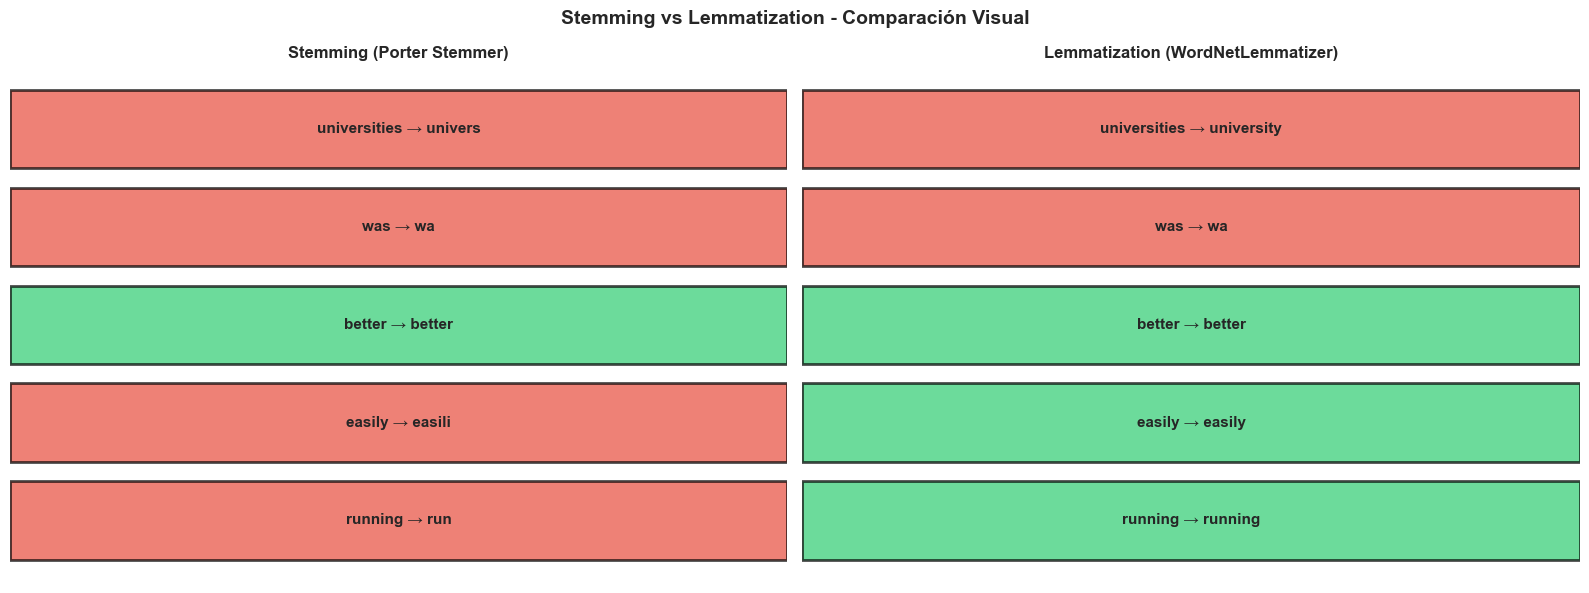

✅ Visualización guardada


In [11]:
# Visualizar diferencias
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stemming vs Lemmatization - Comparación Visual', fontsize=14, fontweight='bold')

# Datos para visualizar
words = ['running', 'easily', 'better', 'was', 'universities']
stems = [stemmer.stem(w) for w in words]
lemmas = [lemmatizer.lemmatize(w) for w in words]

# Gráfico 1: Stemming
ax1 = axes[0]
colors_stem = ['#e74c3c' if stems[i] != words[i] else '#2ecc71' for i in range(len(words))]
ax1.barh(words, [1]*len(words), color=colors_stem, edgecolor='black', linewidth=2, alpha=0.7)
for i, (word, stem) in enumerate(zip(words, stems)):
    ax1.text(0.5, i, f"{word} → {stem}", ha='center', va='center', fontweight='bold', fontsize=11)
ax1.set_xlim(0, 1)
ax1.set_xticks([])
ax1.set_title('Stemming (Porter Stemmer)', fontweight='bold', fontsize=12)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.set_yticks([])

# Gráfico 2: Lemmatization
ax2 = axes[1]
colors_lemma = ['#e74c3c' if lemmas[i] != words[i] else '#2ecc71' for i in range(len(words))]
ax2.barh(words, [1]*len(words), color=colors_lemma, edgecolor='black', linewidth=2, alpha=0.7)
for i, (word, lemma) in enumerate(zip(words, lemmas)):
    ax2.text(0.5, i, f"{word} → {lemma}", ha='center', va='center', fontweight='bold', fontsize=11)
ax2.set_xlim(0, 1)
ax2.set_xticks([])
ax2.set_title('Lemmatization (WordNetLemmatizer)', fontweight='bold', fontsize=12)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_yticks([])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'stemming_vs_lemmatization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Parte 6: Pipeline Completo de Preprocesamiento

In [12]:
def preprocess_text(text, use_lemmatization=True, use_stemming=False, remove_stopwords=True):
    """
    Pipeline completo de preprocesamiento de texto.
    
    Args:
        text: Texto a procesar
        use_lemmatization: Aplicar lemmatization
        use_stemming: Aplicar stemming
        remove_stopwords: Remover stopwords
    
    Returns:
        Texto preprocesado
    """
    # 1. Remover HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # 2. Remover URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 3. Remover emojis y caracteres especiales
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 4. Convertir a minúsculas
    text = text.lower()
    
    # 5. Remover puntuación
    text = re.sub(r'[!@#$%^&*()\-_=\[\]{};\':",.<>?/\\~`]+', ' ', text)
    
    # 6. Normalizar espacios
    text = ' '.join(text.split())
    
    # 7. Tokenización
    tokens = word_tokenize(text)
    
    # 8. Remover stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    
    # 9. Lemmatization o Stemming
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    elif use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    
    # 10. Retornar como string
    return ' '.join(tokens)

print("✅ Función preprocess_text() creada")

✅ Función preprocess_text() creada


In [13]:
print("=" * 70)
print("🔄 PIPELINE COMPLETO DE PREPROCESAMIENTO")
print("=" * 70)

# Procesar las tres reviews reales del IMDB
for i, review in enumerate(example_reviews, 1):
    print(f"\n{'='*70}")
    print(f"REVIEW {i} (IMDB REAL)")
    print(f"{'='*70}")
    
    # Mostrar original (truncado)
    display_orig = review if len(review) <= 150 else review[:150] + "..."
    print(f"\n📝 Original ({len(review)} caracteres):")
    print(f"   {display_orig}\n")
    
    # Procesar
    processed = preprocess_text(review, use_lemmatization=True, remove_stopwords=True)
    
    print(f"✅ Procesada ({len(processed)} caracteres):")
    print(f"   {processed}\n")
    
    # Estadísticas
    original_tokens = len(review.split())
    processed_tokens = len(processed.split())
    reduction = (1 - processed_tokens / original_tokens) * 100
    
    print(f"📊 Estadísticas:")
    print(f"   - Palabras originales: {original_tokens}")
    print(f"   - Palabras procesadas: {processed_tokens}")
    print(f"   - Reducción: {reduction:.1f}%")

🔄 PIPELINE COMPLETO DE PREPROCESAMIENTO

REVIEW 1 (IMDB REAL)

📝 Original (1089 caracteres):
   as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room i...

✅ Procesada (514 caracteres):
   powerful let love becomes reaching journalist lot anyone atmosphere never room heart show year every never going help moment every chest visual movie except several enough current film mine potentially unfortunately get camp movie sometimes movie scary story wonderful seeing character 70 musician heart shadow serious critic one seen landed anyone br show whether history name half br odd two mean boat thought frog script history heart real barrel one bit two script nobody armed acting watch heartfelt film want

📊 Estadísticas:
   - Palabras originales: 211
   - Palabras procesadas: 80
   - Reducción: 62.1%

REVIEW 2 (IMDB REAL)

📝 Original (923 caracteres):
   thought solid thought senator do making to is sp

## Parte 7: Comparación de Opciones de Preprocesamiento

In [14]:
# Comparar diferentes opciones
test_review = example_reviews[0]

print("=" * 70)
print("⚙️  OPCIONES DE PREPROCESAMIENTO")
print("=" * 70)

print(f"\n📝 Review original:")
print(f"   {test_review}\n")

options = [
    ("Sin procesar", test_review),
    ("Solo limpieza", ' '.join(clean_text_step_by_step(test_review).values())),
    ("Limpieza + Tokenización", ' '.join(word_tokenize(' '.join(clean_text_step_by_step(test_review).values()).lower()))),
    ("Con Lemmatization", preprocess_text(test_review, use_lemmatization=True, remove_stopwords=False)),
    ("Con Stemming", preprocess_text(test_review, use_stemming=True, remove_stopwords=False)),
    ("Con Stopwords removido", preprocess_text(test_review, use_lemmatization=True, remove_stopwords=True)),
]

for option_name, text in options:
    words = len(text.split())
    print(f"{option_name:<30} ({words:2d} palabras):")
    print(f"   {text[:80]}...")
    print()

⚙️  OPCIONES DE PREPROCESAMIENTO

📝 Review original:
   as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room it so heart shows to years of every never going help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other in of seen over landed for anyone of br show's to whether from than out themselves history he name half some br of odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but wh

## Parte 8: Análisis de Vocabulario

In [15]:
# Combinar todas las reviews procesadas
all_processed_reviews = [preprocess_text(r) for r in example_reviews]
all_tokens = ' '.join(all_processed_reviews).split()

print("=" * 70)
print("📚 ANÁLISIS DE VOCABULARIO")
print("=" * 70)

print(f"\nTotal de tokens: {len(all_tokens)}")
print(f"Tokens únicos: {len(set(all_tokens))}")
print(f"Tokens únicos / Total: {len(set(all_tokens)) / len(all_tokens):.2%}\n")

print("Frecuencia de palabras:")
word_freq = Counter(all_tokens)
for word, freq in word_freq.most_common(15):
    bar = '█' * freq
    print(f"   {word:<15} {freq:2d} {bar}")

📚 ANÁLISIS DE VOCABULARIO

Total de tokens: 254
Tokens únicos: 134
Tokens únicos / Total: 52.76%

Frecuencia de palabras:
   thought          7 ███████
   show             6 ██████
   br               6 ██████
   senator          6 ██████
   making           6 ██████
   film             4 ████
   one              4 ████
   solid            4 ████
   diverse          4 ████
   budget           4 ████
   love             3 ███
   heart            3 ███
   movie            3 ███
   character        3 ███
   want             3 ███


## Resumen y Conclusiones

### ✅ Lo que aprendimos:

1. **Tokenización**: Dividir texto en palabras/sentencias
   - split() es simple pero imperfecto
   - word_tokenize() de NLTK es más robusto

2. **Limpieza de Texto**: 7 pasos clave
   - HTML tags, URLs, caracteres especiales
   - Convertir a minúsculas
   - Normalizar espacios

3. **Stopwords**: Palabras comunes sin significado
   - Removerlas reduce ruido
   - Mejora eficiencia (menos dimensiones)

4. **Stemming vs Lemmatization**:
   - Stemming: Rápido, pero puede producir palabras raras
   - Lemmatization: Más lento, pero resultados más precisos

5. **Pipeline Completo**: 10 pasos en orden específico
   - Orden importa: HTML → URLs → lowercase → tokens → stopwords → lemmatization

### 🎯 Cuando aplicar cada opción:

| Opción | Usar cuando | No usar cuando |
|--------|-------------|----------------|
| **Lemmatization** | Quieres precisión, tienes corpus pequeño | Dataset muy grande, necesitas velocidad |
| **Stemming** | Necesitas velocidad, corpus muy grande | Precisión es crítica |
| **Stopwords removal** | Texto es largo y repetitivo | Stopwords cargan significado (ej: "not") |
| **Sin procesamiento** | Dataset pre-limpio, embeddings pre-entrenados | Texto muy sucio, modelos clásicos |

### 🎓 Próximos pasos:

En el siguiente notebook:
- **Feature Extraction (TF-IDF)**
- Convertir texto limpio → números
- Entender qué palabras son más importantes

In [16]:
# 🎮 Ejercicio Interactivo: Prueba con tu propio texto
print("=" * 70)
print("🎮 EJERCICIO INTERACTIVO")
print("=" * 70)

# Cambia este texto para experimentar
my_review = "This is AMAZING!!! I absolutely loved this movie. It was fantastic!!!"

print(f"\n📝 Tu review:")
print(f"   {my_review}\n")

print("Resultados de preprocesamiento:\n")

for lemma in [True, False]:
    for stopw in [True, False]:
        label = f"Lemmatization: {lemma}, Stopwords: {stopw}"
        result = preprocess_text(my_review, use_lemmatization=lemma, remove_stopwords=stopw)
        print(f"{label:<40} → {result}\n")

print("💡 Tip: Cambia el valor de 'my_review' y ejecuta de nuevo para probar diferentes textos!")

🎮 EJERCICIO INTERACTIVO

📝 Tu review:
   This is AMAZING!!! I absolutely loved this movie. It was fantastic!!!

Resultados de preprocesamiento:

Lemmatization: True, Stopwords: True     → amazing absolutely loved movie fantastic

Lemmatization: True, Stopwords: False    → this is amazing i absolutely loved this movie it wa fantastic

Lemmatization: False, Stopwords: True    → amazing absolutely loved movie fantastic

Lemmatization: False, Stopwords: False   → this is amazing i absolutely loved this movie it was fantastic

💡 Tip: Cambia el valor de 'my_review' y ejecuta de nuevo para probar diferentes textos!
